# Explainability — XGBoost (SHAP) & SARIMA

All analysis is for **one hotspot, one crime type**. Change the two config lines to switch.

| Model | What we show |
|---|---|
| **XGBoost** | Feature importance · SHAP waterfall for a forecast month · Prediction interval from CV residuals |
| **SARIMA** | Forecast with CI · Forecast decomposition waterfall (baseline + seasonal + trend + ARIMA) |

In [1]:
from pathlib import Path
import sys, warnings

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.2f}'.format)
shap.initjs()

## Configuration

In [2]:
TARGET_LSOA      = 'E01035716'
TARGET_LSOA_NAME = 'Westminster 013G'
EXAMPLE_CRIME    = None   # None = auto-select highest-volume type
HORIZON          = 12

DATA_DIR = next(
    (p for p in [Path.cwd() / 'data', Path.cwd().parent / 'data']
     if (p / 'all_lsoa__monthly_counts.csv').exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError('Cannot find all_lsoa__monthly_counts.csv')

NOTEBOOK_DIR = ROOT / 'notebooks' if (ROOT / 'notebooks').exists() else Path.cwd()
OUTPUT_DIR   = NOTEBOOK_DIR / 'forecast_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CRIME_CACHE = OUTPUT_DIR / f'{TARGET_LSOA}_monthly_crime_type_counts.csv'
CV_CACHE    = OUTPUT_DIR / f'{TARGET_LSOA}_crime_type_forecasts.csv'

print(f'Hotspot : {TARGET_LSOA} / {TARGET_LSOA_NAME}')
print(f'Cache   : {CRIME_CACHE} ({"exists" if CRIME_CACHE.exists() else "will load from main CSV"})')
print(f'CV data : {CV_CACHE} ({"exists — will use for XGBoost CI" if CV_CACHE.exists() else "not found — will fall back to training residuals"})')

Hotspot : E01035716 / Westminster 013G
Cache   : /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_monthly_crime_type_counts.csv (exists)
CV data : /Users/anas/PythonProjects/CBL/notebooks/forecast_outputs/E01035716_crime_type_forecasts.csv (exists — will use for XGBoost CI)


## Load Data and Fit Models

In [3]:
from src.train.data import load_data, build_lsoa_frame
from src.train.models.xgboost import (
    XGBoostGlobalForecaster, build_xgb_global_frame,
    get_xgb_global_features, _crime_type_col,
)
from src.train.models.sarima import SARIMAForecaster
from src.train.config import XGB_LAGS

if CRIME_CACHE.exists():
    monthly_counts = pd.read_csv(CRIME_CACHE, parse_dates=['Month'])
    monthly_counts['Month'] = pd.to_datetime(monthly_counts['Month']).dt.to_period('M').dt.to_timestamp()
    print('Loaded from cache')
else:
    print('Loading from main CSV…')
    full = load_data(DATA_DIR / 'all_lsoa__monthly_counts.csv')
    monthly_counts = full[full['LSOA code'].eq(TARGET_LSOA)].copy()

lsoa_table = build_lsoa_frame(monthly_counts, TARGET_LSOA)
ct_totals  = lsoa_table.groupby('Crime type')['crime_count'].sum().sort_values(ascending=False)

if EXAMPLE_CRIME is None or EXAMPLE_CRIME not in ct_totals.index:
    EXAMPLE_CRIME = ct_totals.index[0]
    print(f'Auto-selected: {EXAMPLE_CRIME}')

xgb_forecaster = XGBoostGlobalForecaster.fit(lsoa_table, extra_features=[])
train_table, active_types = build_xgb_global_frame(lsoa_table)
feature_cols = get_xgb_global_features(crime_types=active_types)
X_train = train_table[feature_cols]
y_train = train_table['crime_count']

crime_frame = lsoa_table[lsoa_table['Crime type'] == EXAMPLE_CRIME].sort_values('Month')
sarima_mdl  = SARIMAForecaster.fit(crime_frame, extra_features=[])
series = crime_frame.set_index('Month')['crime_count'].astype(float).asfreq('MS')

p, d, q    = sarima_mdl._model.order
P, D, Q, m = sarima_mdl._model.seasonal_order

print(f"\nCrime type : {EXAMPLE_CRIME}")
print(f"XGBoost    : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"SARIMA     : ({p},{d},{q})({P},{D},{Q},{m})  on {len(series)} months")

Loaded from cache
Auto-selected: Theft from the person

Crime type : Theft from the person
XGBoost    : 336 rows × 25 features
SARIMA     : (1,0,0)(1,0,0,12)  on 36 months


## Overview

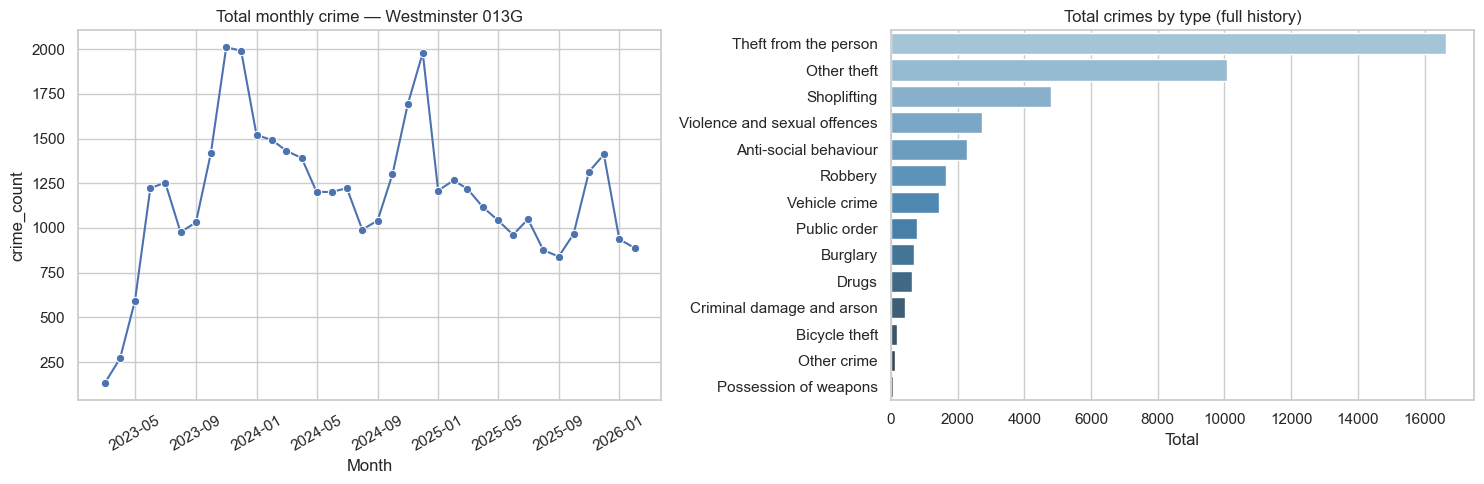

In [4]:
total_monthly = lsoa_table.groupby('Month', as_index=False)['crime_count'].sum().sort_values('Month')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=total_monthly, x='Month', y='crime_count', marker='o', ax=ax1)
ax1.set_title(f'Total monthly crime — {TARGET_LSOA_NAME}')
ax1.tick_params(axis='x', rotation=30)

sns.barplot(y=ct_totals.index, x=ct_totals.values, palette='Blues_d', ax=ax2)
ax2.set_title('Total crimes by type (full history)')
ax2.set_xlabel('Total'); ax2.set_ylabel('')

plt.tight_layout()
plt.show()

---
# Part A — XGBoost

The global model is trained on all crime types together, but we explain it **as if it were a dedicated model for `EXAMPLE_CRIME`** by filtering all analysis to rows where that type is active and hiding the one-hot type column.

In [5]:
ct_col  = _crime_type_col(EXAMPLE_CRIME)
ct_mask = X_train[ct_col] == 1
X_ct    = X_train[ct_mask].copy()
y_ct    = y_train[ct_mask].copy()

ts_cols = [c for c in feature_cols if not c.startswith('ct__')]

explainer = shap.TreeExplainer(xgb_forecaster._model)
shap_all  = explainer.shap_values(X_ct)
shap_ts   = shap_all[:, [feature_cols.index(c) for c in ts_cols]]
expected  = float(explainer.expected_value)

print(f"{EXAMPLE_CRIME}  |  {len(X_ct):,} training rows  |  SHAP baseline: {expected:.2f} crimes/month")

Theft from the person  |  24 training rows  |  SHAP baseline: 84.74 crimes/month


### A1 · Feature Importance for This Crime Type

Mean |SHAP value| computed only on `EXAMPLE_CRIME` rows — shows which features matter specifically for this crime type, not the global average.

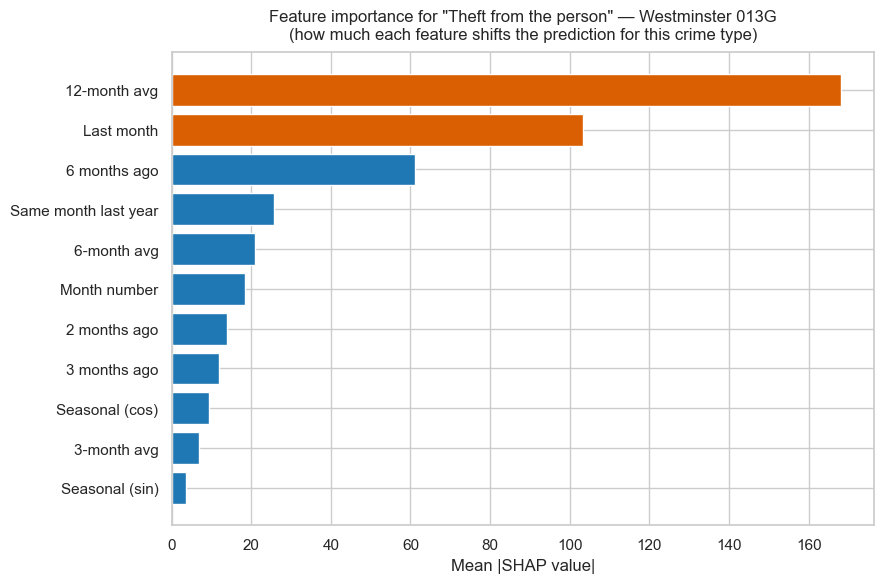

Top 3 drivers: [('12-month avg', '168.01'), ('Last month', '103.42'), ('6 months ago', '61.13')]


In [6]:
ts_labels = {
    'lag_1': 'Last month', 'lag_2': '2 months ago', 'lag_3': '3 months ago',
    'lag_6': '6 months ago', 'lag_12': 'Same month last year',
    'rolling_3_mean': '3-month avg', 'rolling_6_mean': '6-month avg',
    'rolling_12_mean': '12-month avg',
    'month_sin': 'Seasonal (sin)', 'month_cos': 'Seasonal (cos)', 'month_num': 'Month number',
}
readable_ts = [ts_labels.get(c, c) for c in ts_cols]

mean_abs = np.abs(shap_ts).mean(axis=0)
order    = np.argsort(mean_abs)

fig, ax = plt.subplots(figsize=(9, 6))
colours = ['#1f78b4' if mean_abs[i] < mean_abs.max() * 0.5 else '#d95f02' for i in order]
ax.barh([readable_ts[i] for i in order], mean_abs[order], color=colours)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Feature importance for "{EXAMPLE_CRIME}" — {TARGET_LSOA_NAME}\n'
             f'(how much each feature shifts the prediction for this crime type)', pad=10)
plt.tight_layout()
plt.show()

top3 = sorted(zip(ts_cols, mean_abs), key=lambda x: -x[1])[:3]
print('Top 3 drivers:', [(ts_labels.get(c, c), f'{v:.2f}') for c, v in top3])

### A2 · SHAP Waterfall — why the model predicts X for the first forecast month

We build the actual prediction row for Month 1 of the 12-month forecast and compute SHAP on it.
Each bar shows how much one feature pushed the prediction above (orange) or below (blue) the baseline.

The one-hot crime-type column is hidden — we frame this as a dedicated single-type model.

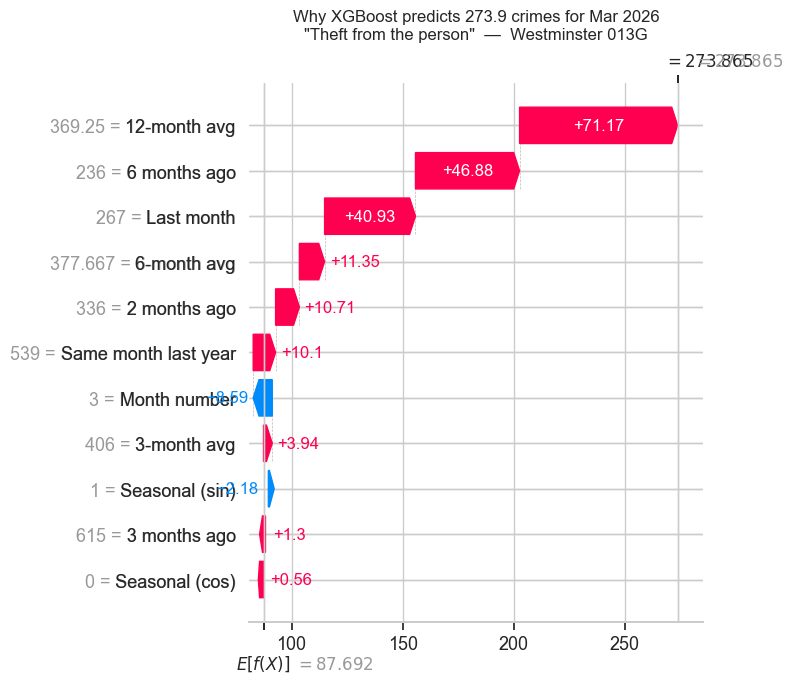

Prediction  : 273.9
Baseline    : 87.7  (long-run average for this crime type)
SHAP total  : 186.2  → final = 273.9


In [7]:
def _build_forecast_row(forecaster, crime_type, month_offset=0):
    history = list(forecaster._histories[crime_type])
    fut_months = pd.date_range(
        forecaster.last_month + pd.offsets.MonthBegin(1), periods=month_offset + 1, freq='MS'
    )
    for i, month in enumerate(fut_months):
        row = {'month_num': month.month,
               'month_sin': float(np.sin(2 * np.pi * month.month / 12)),
               'month_cos': float(np.cos(2 * np.pi * month.month / 12))}
        for lag in XGB_LAGS:
            row[f'lag_{lag}'] = float(history[-lag]) if len(history) >= lag else np.nan
        s = pd.Series(history, dtype=float)
        row['rolling_3_mean']  = float(s.tail(3).mean())
        row['rolling_6_mean']  = float(s.tail(6).mean())
        row['rolling_12_mean'] = float(s.tail(12).mean())
        for ct2 in forecaster._active_types:
            row[_crime_type_col(ct2)] = 1.0 if ct2 == crime_type else 0.0
        pred_df = pd.DataFrame([row], columns=forecaster.feature_cols)
        pred    = max(0.0, float(forecaster._model.predict(pred_df)[0]))
        history.append(pred)
    return pd.DataFrame([row], columns=forecaster.feature_cols), pred

forecast_row_df, fc_pred_m1 = _build_forecast_row(xgb_forecaster, EXAMPLE_CRIME, month_offset=0)
fc_month_1 = xgb_forecaster.last_month + pd.offsets.MonthBegin(1)

shap_fc_row = explainer.shap_values(forecast_row_df)[0]

ts_indices = [feature_cols.index(c) for c in ts_cols]
shap_fc_ts = shap_fc_row[ts_indices]
data_fc_ts = forecast_row_df.iloc[0][ts_cols].values

ct_indices  = [feature_cols.index(c) for c in feature_cols if c.startswith('ct__')]
ct_shap_sum = float(shap_fc_row[ct_indices].sum())
adj_base    = expected + ct_shap_sum

exp_display = shap.Explanation(
    values=shap_fc_ts,
    base_values=adj_base,
    data=data_fc_ts,
    feature_names=readable_ts,
)

plt.figure(figsize=(11, 7))
shap.waterfall_plot(exp_display, max_display=12, show=False)
plt.title(
    f'Why XGBoost predicts {fc_pred_m1:.1f} crimes for {fc_month_1.strftime("%b %Y")}\n'
    f'"{EXAMPLE_CRIME}"  —  {TARGET_LSOA_NAME}',
    pad=10
)
plt.tight_layout()
plt.show()

print(f'Prediction  : {fc_pred_m1:.1f}')
print(f'Baseline    : {adj_base:.1f}  (long-run average for this crime type)')
print(f'SHAP total  : {shap_fc_ts.sum():.1f}  → final = {adj_base + shap_fc_ts.sum():.1f}')

### A3 · XGBoost Forecast with Prediction Interval

XGBoost doesn't produce uncertainty natively.  
**Method: Normalized Adaptive Conformal Prediction  

Non-conformity score: `s_i = |actual_i − predicted_i| / predicted_i`  
Conformal quantile: `q̂ = quantile(s, ⌈(1−α)(1+1/n)⌉)` — guarantees ≥ 80% marginal coverage  
CI: `[forecast × (1−q̂),  forecast × (1+q̂)]`  

The interval **scales with the predicted level** — months forecast at 270 get a proportionally tighter band than months at 1 000, which is the correct behaviour for count data.

Calibration : CV hold-out  (E01035716_crime_type_forecasts.csv, n=12)
n=12  q̂=0.402  → interval = forecast × [0.60, 1.40]


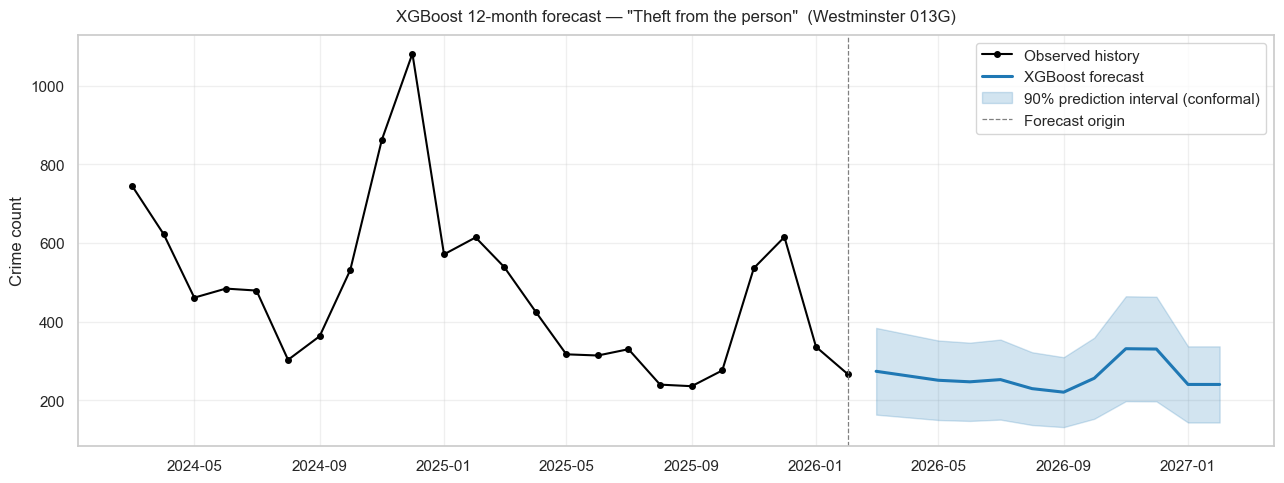


Forecast mean  : 261.4
CI half-width   : ±105.1  (scales with predicted level)
Avg CI range    : 210.3 crimes


In [16]:
COVERAGE = 0.90
alpha    = 1 - COVERAGE

cv_df  = pd.read_csv(CV_CACHE)
fs_col = 'feature_set' if 'feature_set' in cv_df.columns else None
mask   = (
    cv_df['Crime type'].eq(EXAMPLE_CRIME)
    & cv_df['model'].eq('XGBoost')
    & cv_df['status'].eq('ok')
)
if fs_col:
    mask &= cv_df[fs_col].isin({'baseline', 'without_temperature', ''})
cal = cv_df[mask].dropna(subset=['actual', 'predicted'])

y      = cal['actual'].values.astype(float)
yhat   = np.clip(cal['predicted'].values.astype(float), 0.1, None)
scores = np.abs(y - yhat) / yhat
ci_source = f'CV hold-out  ({CV_CACHE.name}, n={len(scores)})'

n       = len(scores)
q_level = min((1 - alpha) * (1 + 1 / n), 1.0)
q_hat   = float(np.quantile(scores, q_level))

print(f'Calibration : {ci_source}')
print(f'n={n}  q̂={q_hat:.3f}  → interval = forecast × [{1-q_hat:.2f}, {1+q_hat:.2f}]')

xgb_fc        = xgb_forecaster.predict_for_crime_type(EXAMPLE_CRIME, HORIZON)
future_months = pd.date_range(
    xgb_forecaster.last_month + pd.offsets.MonthBegin(1), periods=HORIZON, freq='MS'
)
fc_safe  = np.clip(xgb_fc, 0.1, None)
ci_lower = np.clip(fc_safe * (1 - q_hat), 0, None)
ci_upper = fc_safe * (1 + q_hat)

hist_plot = series.iloc[-24:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hist_plot.index, hist_plot.values, color='black', lw=1.5,
        marker='o', ms=4, label='Observed history')
ax.plot(future_months, xgb_fc, color='#1f78b4', lw=2.2, label='XGBoost forecast')
ax.fill_between(future_months, ci_lower, ci_upper,
                color='#1f78b4', alpha=0.2,
                label=f'{int(COVERAGE*100)}% prediction interval (conformal)')
ax.axvline(series.index[-1], color='grey', ls='--', lw=0.9, label='Forecast origin')
ax.set_ylabel('Crime count')
ax.set_title(f'XGBoost 12-month forecast — "{EXAMPLE_CRIME}"  ({TARGET_LSOA_NAME})', pad=10)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nForecast mean  : {xgb_fc.mean():.1f}')
print(f'CI half-width   : ±{xgb_fc.mean()*q_hat:.1f}  (scales with predicted level)')
print(f'Avg CI range    : {(ci_upper - ci_lower).mean():.1f} crimes')

---
# Part B — SARIMA

In [9]:
# SARIMA forecast + CI (always available from pmdarima)
SARIMA_HORIZON = HORIZON
fc_vals, ci = sarima_mdl._model.predict(n_periods=SARIMA_HORIZON, return_conf_int=True, alpha=0.10)
fc_vals = np.clip(fc_vals, 0, None)
ci      = np.clip(ci,      0, None)
sarima_future = pd.date_range(
    series.index[-1] + pd.offsets.MonthBegin(1), periods=SARIMA_HORIZON, freq='MS'
)

### B1 · Time Series Decomposition

Splits the historical series into what SARIMA models against: trend + repeating seasonal cycle + residual noise.

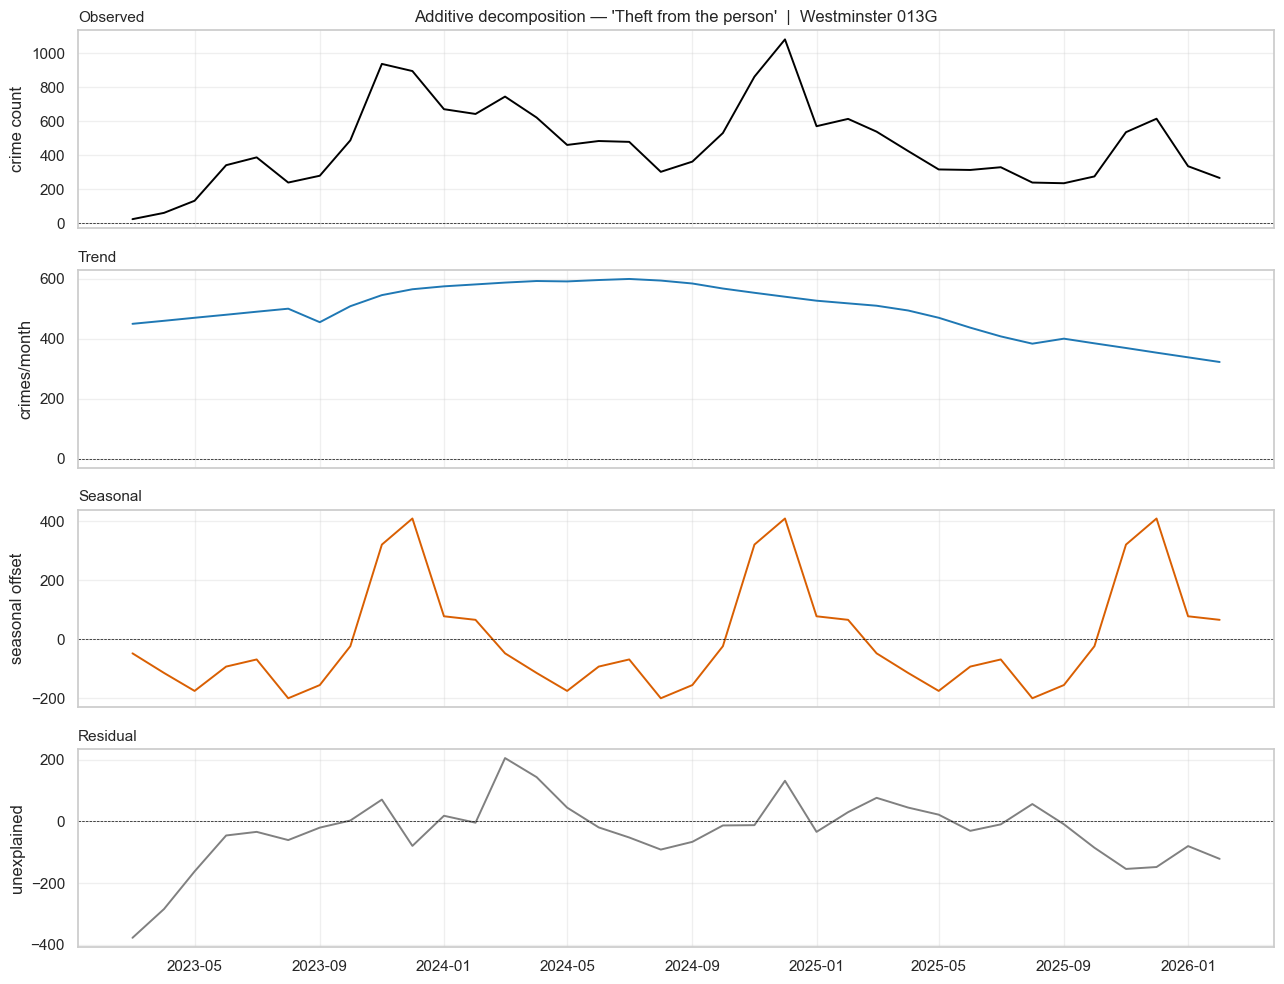

Variance explained:
  Seasonal :  58.9%  ← repeating annual pattern
  Trend    :  11.7%  ← long-run direction
  Residual :  20.3%  ← what ARMA captures


In [10]:
decomp = seasonal_decompose(series, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, (data, title, colour, ylabel) in zip(axes, [
    (series,          'Observed',  'black',     'crime count'),
    (decomp.trend,    'Trend',     '#1f78b4',   'crimes/month'),
    (decomp.seasonal, 'Seasonal',  '#d95f02',   'seasonal offset'),
    (decomp.resid,    'Residual',  'grey',      'unexplained'),
]):
    ax.plot(data, color=colour, lw=1.4)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11, loc='left')
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3)
axes[0].set_title(f"Additive decomposition — '{EXAMPLE_CRIME}'  |  {TARGET_LSOA_NAME}", fontsize=12)
plt.tight_layout(); plt.show()

tv = series.var()
print('Variance explained:')
print(f'  Seasonal : {decomp.seasonal.var()/tv*100:5.1f}%  ← repeating annual pattern')
print(f'  Trend    : {decomp.trend.var()/tv*100:5.1f}%  ← long-run direction')
print(f'  Residual : {decomp.resid.dropna().var()/tv*100:5.1f}%  ← what ARMA captures')

### B2 · SARIMA Forecast with Confidence Intervals

Unlike XGBoost, SARIMA produces natural probability intervals — they widen further into the future as uncertainty compounds.

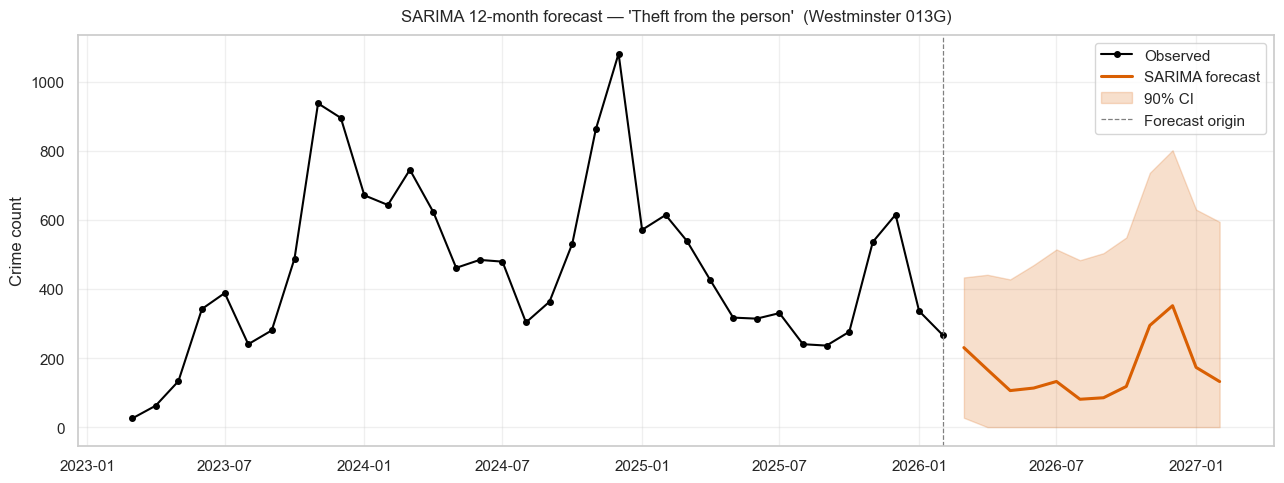

Forecast mean  : 165.1
Mean CI width  : 546.2  (±165% uncertainty)


In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
hist = series.iloc[-36:]
ax.plot(hist.index, hist.values, color='black', lw=1.5, marker='o', ms=4, label='Observed')
ax.plot(sarima_future, fc_vals, color='#d95f02', lw=2.2, label='SARIMA forecast')
ax.fill_between(sarima_future, ci[:,0], ci[:,1], color='#d95f02', alpha=0.2, label='90% CI')
ax.axvline(series.index[-1], color='grey', ls='--', lw=0.9, label='Forecast origin')
ax.set_ylabel('Crime count')
ax.set_title(f"SARIMA 12-month forecast — '{EXAMPLE_CRIME}'  ({TARGET_LSOA_NAME})", pad=10)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ci_w = ci[:,1] - ci[:,0]
print(f'Forecast mean  : {fc_vals.mean():.1f}')
print(f'Mean CI width  : {ci_w.mean():.1f}  (±{ci_w.mean()/2/max(fc_vals.mean(),1)*100:.0f}% uncertainty)')

### B3 · SARIMA Forecast Decomposition

Breaks each forecast month into four additive parts that explain WHERE the number comes from — equivalent to the SHAP waterfall but built from SARIMA's statistical structure.

| Component | Meaning |
|---|---|
| **Baseline** | Long-run average crime level for this type |
| **Seasonal** | How much higher/lower this calendar month typically is |
| **Trend** | Recent upward or downward drift extrapolated forward |
| **ARIMA correction** | What the autoregressive memory adds on top |

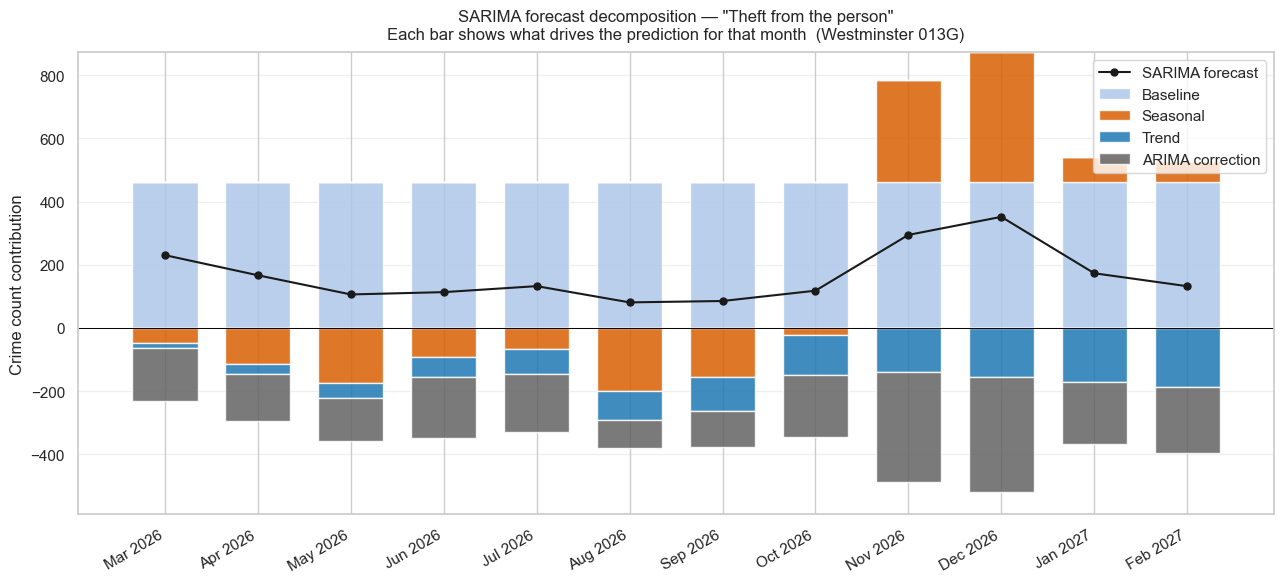

In [12]:
baseline = float(series.mean())

seasonal_by_month = (
    decomp.seasonal.groupby(decomp.seasonal.index.month).mean().to_dict()
)

trend_vals  = decomp.trend.dropna()
n_fit       = min(6, len(trend_vals))
trend_slope = float(np.polyfit(range(n_fit), trend_vals.iloc[-n_fit:].values, 1)[0]) if n_fit >= 2 else 0.0

components = []
for i, (month, fc) in enumerate(zip(sarima_future, fc_vals)):
    seas_c  = seasonal_by_month.get(month.month, 0.0)
    trend_c = trend_slope * (i + 1)
    arima_c = float(fc) - baseline - seas_c - trend_c
    components.append({
        'Month':            month,
        'Baseline':         baseline,
        'Seasonal':         seas_c,
        'Trend':            trend_c,
        'ARIMA correction': arima_c,
        'Forecast':         float(fc),
    })

comp_df = pd.DataFrame(components).set_index('Month')
decomp_cols = ['Baseline', 'Seasonal', 'Trend', 'ARIMA correction']
colours_map = {
    'Baseline':          '#aec7e8',
    'Seasonal':          '#d95f02',
    'Trend':             '#1f78b4',
    'ARIMA correction':  '#636363',
}

fig, ax = plt.subplots(figsize=(13, 6))

bottom_pos = np.zeros(len(comp_df))
bottom_neg = np.zeros(len(comp_df))
x = np.arange(len(comp_df))

for col in decomp_cols:
    vals = comp_df[col].values.astype(float)
    pos  = np.where(vals >= 0, vals, 0)
    neg  = np.where(vals <  0, vals, 0)
    ax.bar(x, pos, bottom=bottom_pos, label=col, color=colours_map[col], width=0.7, alpha=0.85)
    ax.bar(x, neg, bottom=bottom_neg, color=colours_map[col], width=0.7, alpha=0.85)
    bottom_pos = bottom_pos + pos
    bottom_neg = bottom_neg + neg

ax.plot(x, comp_df['Forecast'].values, 'ko-', lw=1.5, ms=5, label='SARIMA forecast', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([m.strftime('%b %Y') for m in comp_df.index], rotation=30, ha='right')
ax.axhline(0, color='black', lw=0.7)
ax.set_ylabel('Crime count contribution')
ax.set_title(
    f'SARIMA forecast decomposition — "{EXAMPLE_CRIME}"\n'
    f'Each bar shows what drives the prediction for that month  ({TARGET_LSOA_NAME})',
    pad=10
)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### B4 · Single-Month Decomposition Waterfall

Same information as B3 but as a step-by-step waterfall for one specific forecast month — mirrors the SHAP waterfall in Part A.

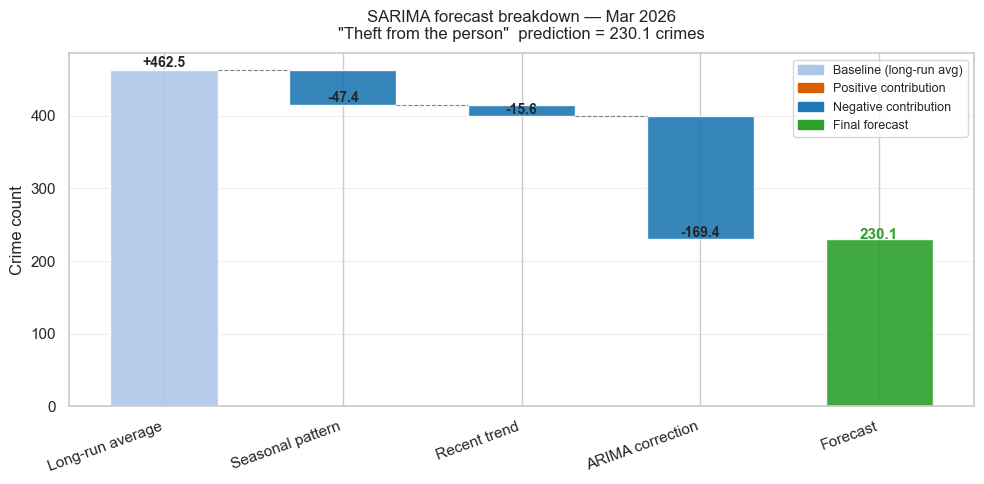


Mar 2026 — "Theft from the person"
  Long-run average         : +462.5
  Seasonal pattern         : -47.4
  Recent trend             : -15.6
  ARIMA correction         : -169.4
  Forecast                 : 230.1


In [13]:
EXPLAIN_MONTH_IDX = 0   # 0 = first forecast month, change to any 0–11

row   = components[EXPLAIN_MONTH_IDX]
month = row['Month'].strftime('%b %Y')

steps = [
    ('Long-run average',   row['Baseline']),
    ('Seasonal pattern',   row['Seasonal']),
    ('Recent trend',       row['Trend']),
    ('ARIMA correction',   row['ARIMA correction']),
]

labels = [s[0] for s in steps] + ['Forecast']
values = [s[1] for s in steps]
cumsum = np.concatenate([[0], np.cumsum(values)])
starts = cumsum[:-1]
final  = float(row['Forecast'])

fig, ax = plt.subplots(figsize=(10, 5))

for i, (label, val) in enumerate(steps):
    colour = '#aec7e8' if i == 0 else ('#d95f02' if val >= 0 else '#1f78b4')
    ax.bar(i, abs(val), bottom=min(starts[i], starts[i] + val),
           color=colour, width=0.6, alpha=0.9)
    ax.text(i, starts[i] + val + (0.3 if val >= 0 else -0.8),
            f'{val:+.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    if i < len(steps) - 1:
        ax.plot([i + 0.3, i + 0.7], [starts[i + 1], starts[i + 1]],
                color='grey', lw=0.8, ls='--')

ax.bar(len(steps), final, color='#2ca02c', width=0.6, alpha=0.9)
ax.text(len(steps), final + 0.3, f'{final:.1f}', ha='center', fontsize=11,
        fontweight='bold', color='#2ca02c')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Crime count')
ax.axhline(0, color='black', lw=0.7)
ax.set_title(
    f'SARIMA forecast breakdown — {month}\n'
    f'"{EXAMPLE_CRIME}"  prediction = {final:.1f} crimes',
    pad=10
)

legend_patches = [
    mpatches.Patch(color='#aec7e8', label='Baseline (long-run avg)'),
    mpatches.Patch(color='#d95f02', label='Positive contribution'),
    mpatches.Patch(color='#1f78b4', label='Negative contribution'),
    mpatches.Patch(color='#2ca02c', label='Final forecast'),
]q
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n{month} — "{EXAMPLE_CRIME}"')
for label, val in steps:
    print(f'  {label:25s}: {val:+.1f}')
print(f'  {"Forecast":25s}: {final:.1f}')